У цьому ДЗ ми попрактикуємось моделювати часові ряди на даних з [Store Item Demand Forecasting Challenge](https://www.kaggle.com/competitions/demand-forecasting-kernels-only/overview). Ми будемо працювати лише з тренувальними даними цього змагання і задача у нас буде дещо змінена. Фокус буде на пошуці найкращої моделі, експериментах і використанні функціоналу `darts`.

Якщо якісно попрацювати в цьому завданні - це буде чудовий приклад проєкту для вашого портфоліо: "спрогнозував(-ла) поденні продажі на 1 міс для 50 товарів в 10 магазинах" звучить вражаюче! Але ми в рамках ДЗ для оптимізації часу сконцентруємось на моделюванні продажів одного товару в одному магазині.

**Задача**

Вам надано дані про продажі товарів у магазинах за 5 років. Хочемо навчитись передачати продажі в наступному місяці поденно кожного з 50 товарів у кожному з 10 магазинів. Відповідно будемо проводити експерименти, аби знайти найкращу модель для цього.

На відміну від змагання, ми будемо використовувати метрику МАРЕ (Mean Absolute Percentage Error) замість SMAPE (Symmetric Mean Absolute Percentage Error). Проте, ви також можете розрахувати SMAPE і подати свої результати через late submission на Kaggle.

1. Завантажуємо дані в Pandas.

  1. Завантажте дані з файлу `train.csv.zip` за допомогою бібліотеки Pandas.
  2. Перетворіть колонку `date` на формат `datetime`.
  3. Встановіть колонку `date` як індекс для датафрейму.
  4. Виведіть перші 10 рядків отриманого датафрейму та інформацію про датафрейм.

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import plotly.express as px
import seaborn as sns

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_predict

In [2]:
data = pd.read_csv('train.csv')

In [3]:
data['date'] = pd.to_datetime(data['date'])
data.set_index('date', inplace=True)

In [4]:
data.head(10)


,store,item,sales
date,,,
2013-01-01,1,1,13
2013-01-02,1,1,11
2013-01-03,1,1,14
2013-01-04,1,1,13
2013-01-05,1,1,10
2013-01-06,1,1,12
2013-01-07,1,1,10
2013-01-08,1,1,9
2013-01-09,1,1,12


  2. Давайте трошки зрозуміємо дані. У нас 10 магазинів і 50 айтемів в кожному. Хочемо зрозуміти, чи відрізняється динаміка по кожному айтему в магазинах. Як би ви це візуалізували? Побудуйте 3 графіка, які вам допоможуть. Можна використати будь-який інструмент: matplotlib, seaborn, plotly.

  Напишіть висновок з побудованих вами візуалізацій.
  
    **Підказка**: я б спробувала вивести середнє значення і довірчий інтервал (який включає весь діапазон значень з різних магазинів) для динаміки кожного айтема, або принаймні для декількох айтемів, аби зрозуміти тенденцію.



In [ ]:
plt.figure(figsize=(15, 6))
sns.lineplot(data=data, x='date', y='sales', errorbar='sd')
plt.title('Середні продажі товарів')
plt.grid(True, alpha=0.3)
plt.show()

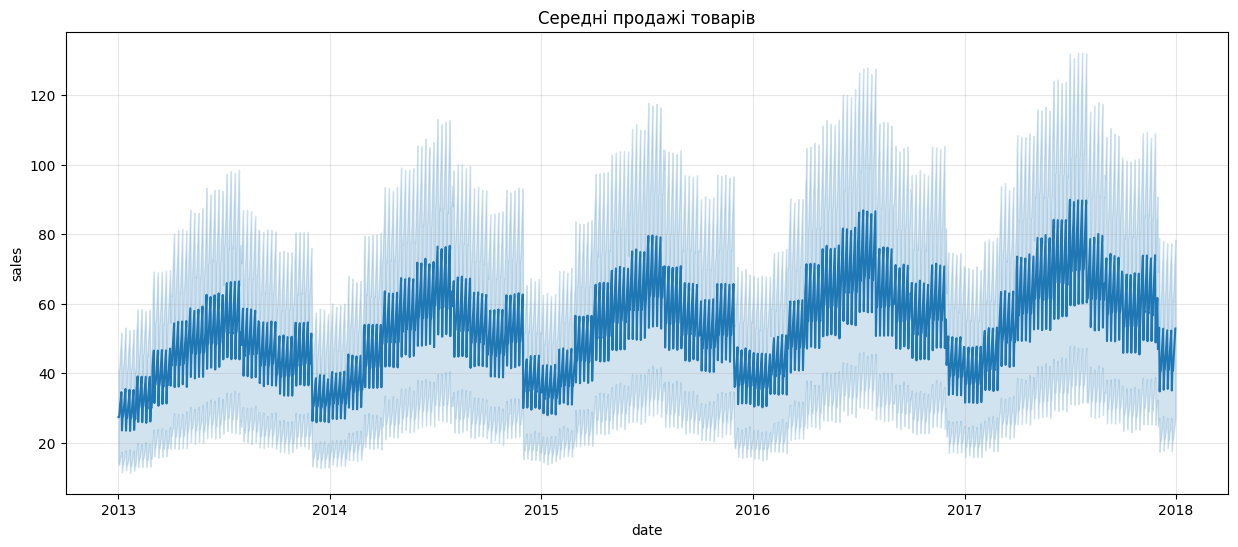

З графіку видно, що відповідно середніх продажів всіх товарів сезонність ярко виражена(зростання у середині року і зменшення у кінці).Найчастіший обсяг продажів (синій колір) чітко видно посередені і віднього вгору та вниз(блакийний) розкид продажів

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=data.reset_index(), x='store', y='sales')
plt.title('Розподіл продажів всіх товарів у розрізі магазинів')
plt.show()

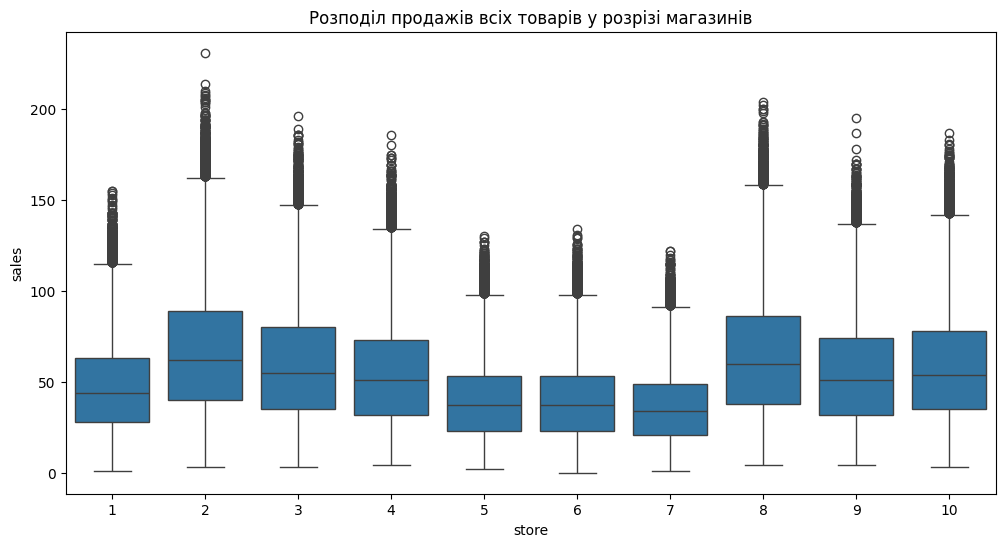

З візуалізаціїї видно, що найбільші медіанні продажі у магазинах 2 та 8. у магазинах 5,6, 7 медіанні продажі менше серед інших.  У кожному магазині спостерігаються викиди.

In [ ]:

pivot_data = data.reset_index()
pivot_data['year'] = pivot_data['date'].dt.year
pivot_data['month'] = pivot_data['date'].dt.month


monthly_sales = pivot_data.pivot_table(index='month', columns='year', values='sales', aggfunc='mean')

plt.figure(figsize=(10, 8))
sns.heatmap(monthly_sales, annot=True, fmt=".1f", cmap='YlGnBu')
plt.title('Середні щомісячні продажі по роках (Сезонність)')
plt.show()

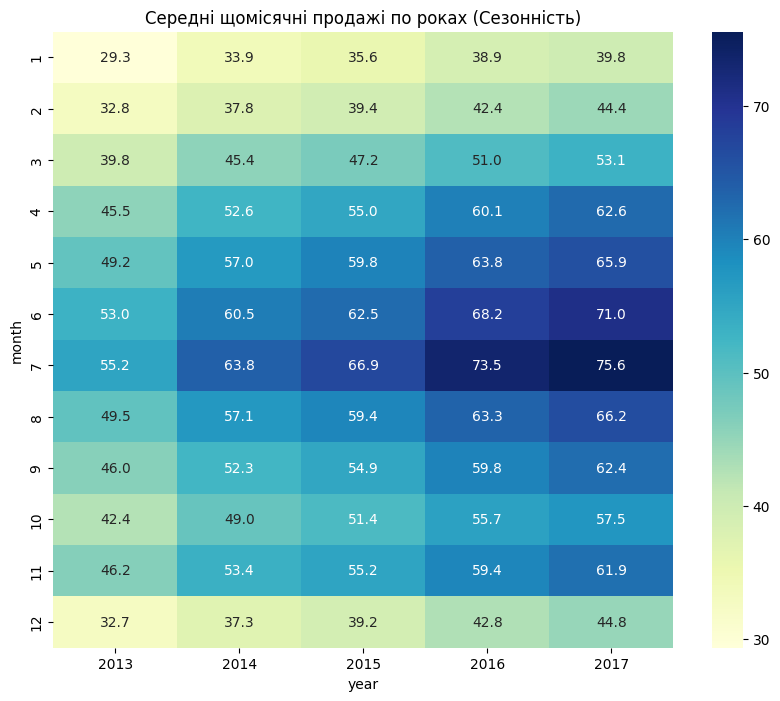

Як було видно і з першого графіку сезонність доволі виражена, а саме найбільші продажі спостерігаються у липні, а в кінці та напочатку вони найнижчі.

3. **Для початку проаналізуємо лише один ряд, а далі зможемо зациклити тренування моделей.**
  
  Виберіть підмножину даних, що відповідає продажам товару з `item == 1` у магазині з `store == 1`.

  Зробіть декомпозицію цього рядку за адитивною моделлю на тренд, сезонність і залишки з бібліотекою `statsmodels`.

  Зробіть висновки з отриманих візуалізацій. Чи щось би могло вам допомогти ліпше зрозуміти ці візуалізації? (з точки зору обробки даних)

In [8]:
one_item_data = data[(data['store'] == 1) & (data['item'] == 1)]['sales']


In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition_plot_multi = seasonal_decompose(one_item_data,
                                              model='additive', period=365)
decomposition_plot_multi.plot()
plt.show()

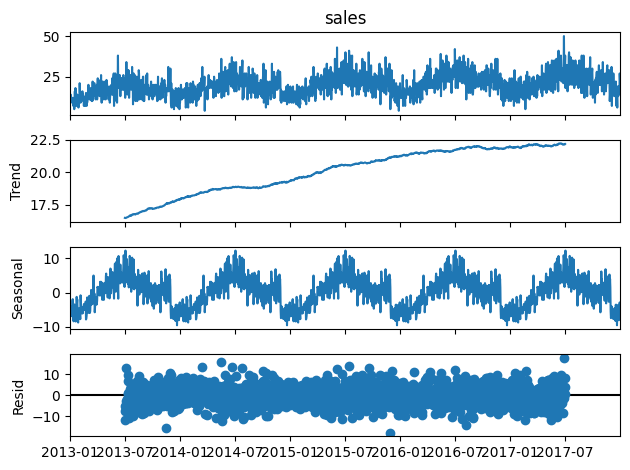

З отриманих даних видно що тренд зростає.

Як було відмічено раніше сезонність ярко виражена (пік середина року).

Залишки коливаються у проміжну від 10 до -10 але є і більші значення.

4. Зі створеної підможени даних в попередньому пункті створіть обʼєкт класу `TimeSeries` в `darts` лише для колонки `sales`.

In [10]:
!pip install darts --quiet

In [11]:
from darts import TimeSeries

In [12]:
df_for_darts = one_item_data.to_frame().reset_index()
series = TimeSeries.from_dataframe(df_for_darts ,time_col='date', value_cols='sales')

In [13]:
print(series)

            sales
date             
2013-01-01   13.0
2013-01-02   11.0
2013-01-03   14.0
2013-01-04   13.0
2013-01-05   10.0
...           ...
2017-12-27   14.0
2017-12-28   19.0
2017-12-29   15.0
2017-12-30   27.0
2017-12-31   23.0

shape: (1826, 1, 1), freq: D, size: 14.27 KB


In [ ]:
series.plot()

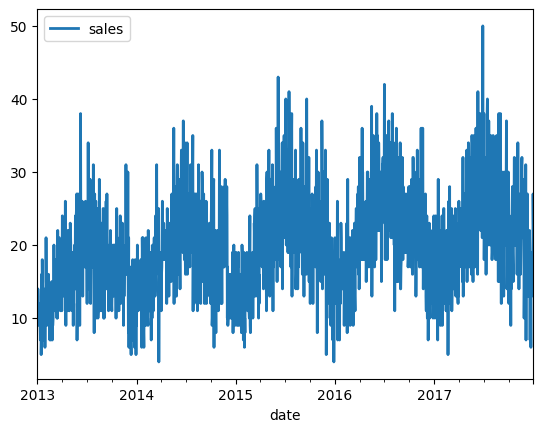

5. Використовуючи метод `series.split_before` розбийте дані на тренування і валідацію так, аби валідація починалась з `2017-10-01` включно.

  Візуалізуйте на одному графіку тренувальну і валідаційну частину як було показано в лекції.

In [ ]:
train, val = series.split_before(pd.Timestamp("2017-10-01"))
train.plot(label="training")
val.plot(label="validation")

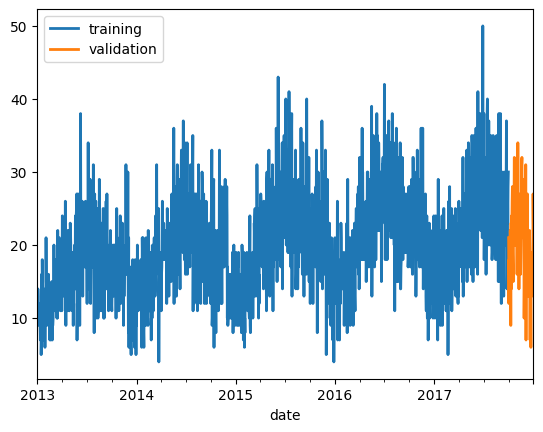

6. Побудуйте часткову автокореляційну фукнцію для цього нашого ряду в `series`. Напишіть висновки - які лаги є важливими для прогнозування?

In [ ]:
from darts.utils.statistics import plot_acf


plot_acf(series, max_lag=50)
plt.title('Autocorrelation Function (ACF)')
plt.show()

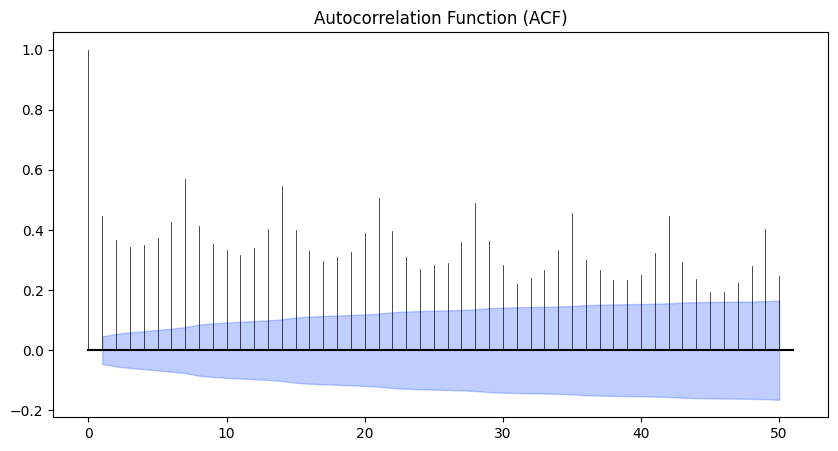

З автокореляційної функції видно сезонність кожні 7 днів.
Вищі значення на 7,14,21... лагах.
З часом значення поступово зменшуються.


7. Виявіть сезональність тренувального ряду використовуючи фукнкцію `check_seasonality` з `darts`.

In [ ]:
from darts.utils.statistics import plot_acf, check_seasonality

plot_acf(train, m=7, alpha=0.05, max_lag=24)

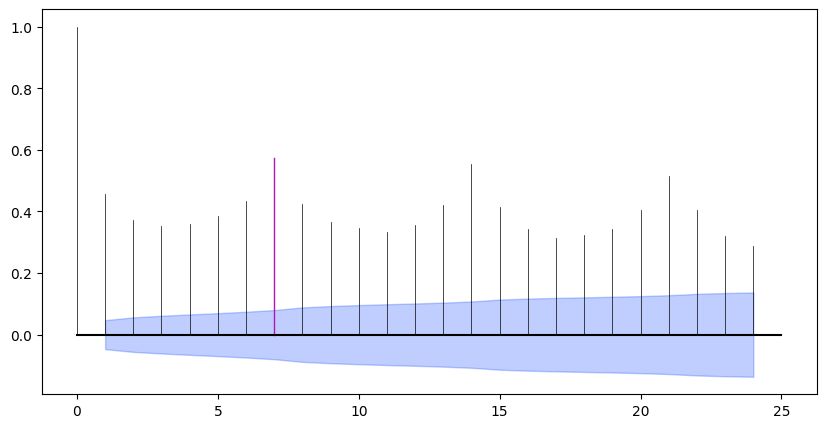

Спостерігається тижнева сезоність продажі товару 1.

8. Побудуйте наївну модель NaiveSeasonal + NaieDrift для прогнозування даних. Кількість кроків для прогнозування визначіть зі свого аналізу в попередніх пунктах. Візуалізайте передбачення проти справжніх даних так, аби було видно якість передбачень. Зробіть висновок про модель. Вона точна?

  Якщо у вас є ідеї, як поліпшити якість передбачення саме наївними моделями - реалізуйте їх в цьому пункті :)

In [18]:
!pip install pytorch-lightning --quiet

In [19]:
from darts.models import NaiveSeasonal, NaiveDrift, NaiveEnsembleModel

In [ ]:
seasonal_component = NaiveSeasonal(K=7)
drift_component = NaiveDrift()
seasonal_model= NaiveEnsembleModel(forecasting_models=[seasonal_component, drift_component])
seasonal_model.fit(train)
seasonal_forecast = seasonal_model.predict(36)

series.plot(label="actual")
seasonal_forecast.plot(label="naive prediction (K=7)")

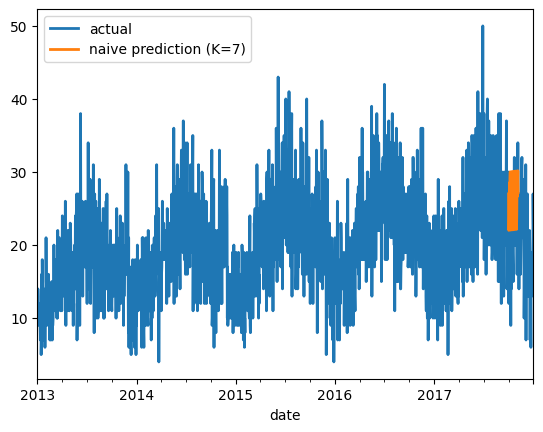

In [ ]:
data_2017 = series.slice(pd.Timestamp("2017-01-01"), series.end_time())
plt.figure(figsize=(12, 6))

data_2017.plot(label="Продажі 2017", color="royalblue")
seasonal_forecast.plot(label="Naive Forecast", color="darkorange", lw=2)

plt.title("Детальний перегляд прогнозу наприкінці 2017 року")
plt.legend()
plt.show()

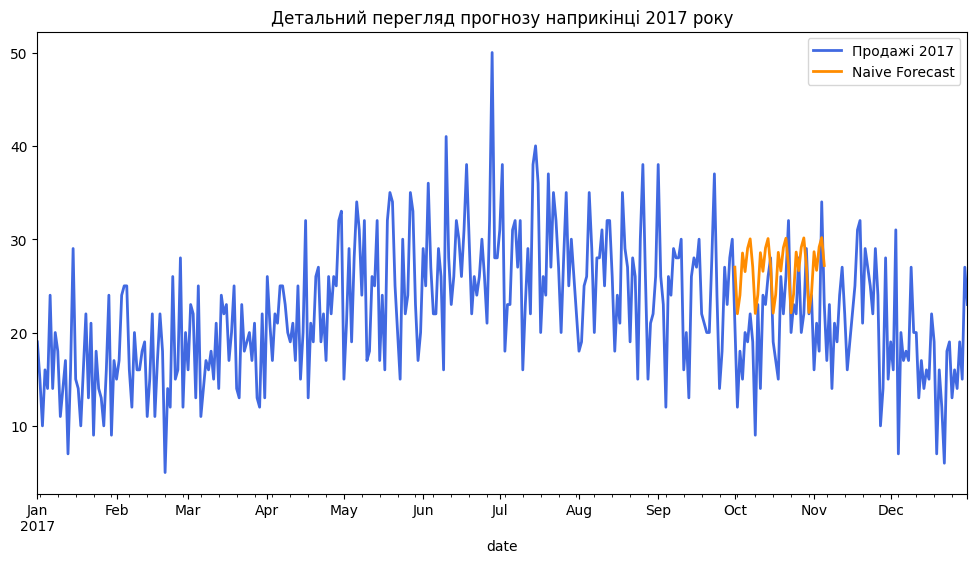

Ця модель просто повторює продажі за останній тиждень і ці прогнози не відповідають ні тренду ні сезонності

9. Обчисліть помилку прогнозу на валідації наївною моделлю з mape. Далі для всіх моделей необхідно обчислювати помилку прогнозу на валідації.

In [22]:
from darts.metrics import mape

print(
    f"Mean absolute percentage error for the combined naive drift + seasonal: {mape(series, seasonal_forecast):.2f}%."
)

Mean absolute percentage error for the combined naive drift + seasonal: 35.04%.


10. Натренуйте XBGModel з `darts` для передбачення наших даних. Можна додавати всі додаткові ознаки, які вважаєте за потрібне, наприклад, ознаки з дати. Зробіть висновок про якість моделі.

In [23]:
def eval_forecast(model, val, forecast):
  mape_ = mape(val, forecast)
  print(f"model {model} obtains MAPE: {mape_:.2f}%")
  return mape_

def fit_eval_model(model):
    model.fit(train)
    forecast = model.predict(len(val))
    eval_forecast(model, val, forecast)

In [24]:
print(train)

            sales
date             
2013-01-01   13.0
2013-01-02   11.0
2013-01-03   14.0
2013-01-04   13.0
2013-01-05   10.0
...           ...
2017-09-26   18.0
2017-09-27   27.0
2017-09-28   23.0
2017-09-29   28.0
2017-09-30   30.0

shape: (1734, 1, 1), freq: D, size: 13.55 KB


In [25]:
from darts.models import XGBModel
from darts.dataprocessing.transformers import Scaler

def enrich_with_date_features(df):
  # Feature Extraction
  df["hour"] = df['date'].dt.hour
  df["dayofweek"] = df['date'].dt.dayofweek
  df["quarter"] = df['date'].dt.quarter
  df["month"] = df['date'].dt.month
  df["year"] = df['date'].dt.year
  df["dayofyear"] = df['date'].dt.dayofyear
  df["sin_day"] = np.sin(df["dayofyear"])
  df["cos_day"] = np.cos(df["dayofyear"])
  df["dayofmonth"] = df['date'].dt.day
  return df

train_df = pd.DataFrame({"sales": train.values().flatten()}, index=train.time_index).reset_index()
val_df = pd.DataFrame({"sales": val.values().flatten()}, index=val.time_index).reset_index()

# Додаємо ознаки дати
# Додавання ознак дати
train_transformed = enrich_with_date_features(train_df)
val_transformed = enrich_with_date_features(val_df )


# Масштабування даних
scaler = Scaler()
train_transformed = scaler.fit_transform(train)
test_transformed = scaler.transform(val)


# Побудова моделі XGBoost
model_xgb = XGBModel(
    lags=7,
    output_chunk_length=2,
    n_estimators=50,
    max_depth=7,
    learning_rate=0.1,
   subsample=0.8,
    colsample_bytree=0.8
)

# Тренування моделі
model_xgb.fit(train_transformed)
pred = model_xgb.predict(6)
pred.values()

array([[0.43741688],
       [0.34042102],
       [0.43468612],
       [0.43602687],
       [0.4382632 ],
       [0.49363774]], dtype=float32)

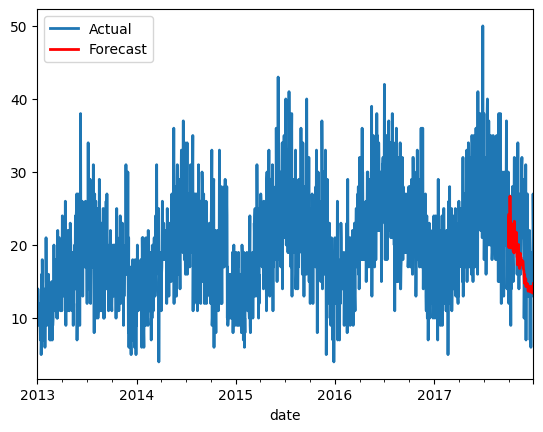

model XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=50,
             n_jobs=None, num_parallel_tree=None, ...) obtains MAPE: 25.95%


In [26]:
forecast = scaler.inverse_transform(model_xgb.predict(len(val)))
series.plot(label='Actual')
forecast.plot(label='Forecast', color='red')
plt.legend()
plt.show()
eval_forecast(model_xgb, val, forecast);

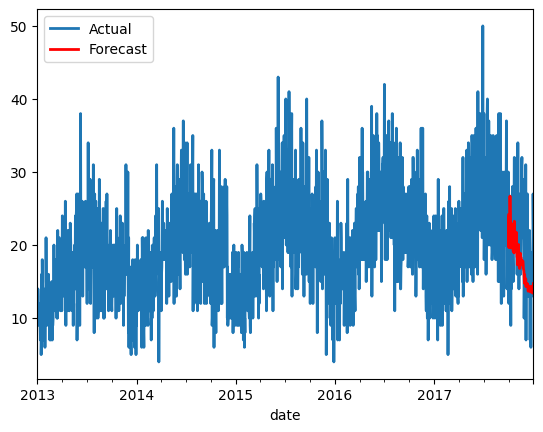

In [ ]:
data_2017 = series.slice(pd.Timestamp("2017-01-01"), series.end_time())
plt.figure(figsize=(12, 6))

data_2017.plot(label="Продажі 2017", color="royalblue")
forecast.plot(label="XGBModel", color="darkorange", lw=2)

plt.title("Детальний перегляд прогнозу наприкінці 2017 року")
plt.legend()
plt.show()

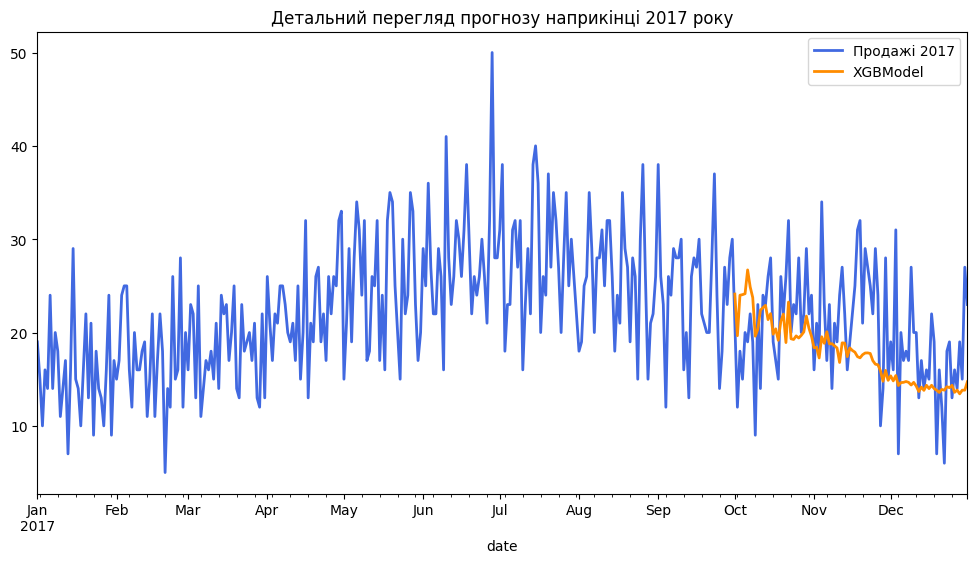

Натренована модель  XBGModel показує кращі результати ніж попередня, але все одно занадто високі.

11. Натренуйте модель ExponentialSmoothing та зробіть висновок про її якість.

In [ ]:
from darts.models import ExponentialSmoothing
def plot_results(series, forecast):
  # Візуалізація результатів
  series.plot(label='Actual')
  forecast.plot(label='Forecast', color='red')
  plt.legend()
  plt.show()

def fit_and_plot(model, series, train, val):
  model.fit(train)
  forecast = model.predict(len(val))
  series_2017 = series.slice(pd.Timestamp("2017-01-01"), series.end_time())
  plot_results(series_2017, forecast)
  eval_forecast(model, val, forecast);

model_ex = ExponentialSmoothing(seasonal_periods=7)
fit_and_plot(model_ex , series, train, val)

model ExponentialSmoothing(seasonal_periods=7) obtains MAPE: 39.01%

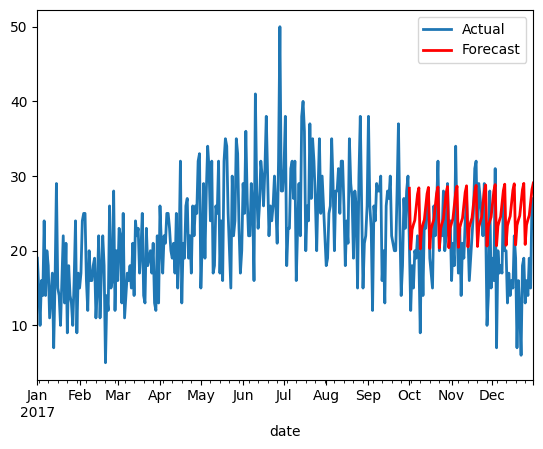

Сезонність видно але показник MAPE: 39.01%   все ще високий

12. Натренуйте модель ARIMA, параметри оберіть самостійно.Зробіть висновок про її якість.

In [ ]:
from darts.models import ARIMA

# Побудова та тренування моделі ARIMA
model_arima = ARIMA(p=7, d=1, q=1)
fit_and_plot(model_arima , series, train, val)

model ARIMA(p=7, q=1) obtains MAPE: 39.53%

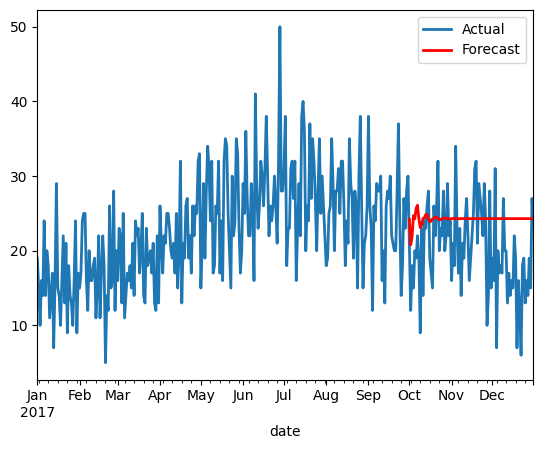

13. Знайдіть оптимальні параметри моделі ARIMA з допомогою AutoARIMA моделі. Виконайте пошук параметрів, виведіть, які паарметри виявились оптимальними і обчисліть якість моделі. Чи поліпшилась якість порівняно з попереднім експериментом?

In [30]:
#!pip install statsforecast pmdarima --quiet

In [ ]:
from darts.models import AutoARIMA
model_auto = AutoARIMA(start_p=10, max_p=14, start_q=1)
model_auto.fit(train)
display(model_auto)
forecast = model_auto.predict(len(val))
fit_and_plot(model_auto, series, train, val)


AutoARIMA(add_encoders=None, quantiles=None, random_state=None, start_p=10, max_p=14, start_q=1)

model AutoARIMA(start_p=10, max_p=14, start_q=1) obtains MAPE: 39.08%

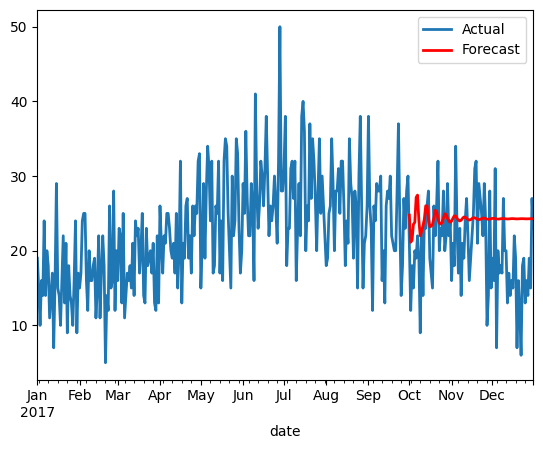

AutoARIMA трохи покращілась на 0,45%

14. Натренуйте модель Prophet та зробіть висновок про її якість.

In [ ]:
from darts.models import Prophet


model_prop = Prophet()
model_prop.fit(train)

forecast = model_prop.predict(len(val))


fit_and_plot(model_prop, series, train, val)


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
model Prophet() obtains MAPE: 23.80%

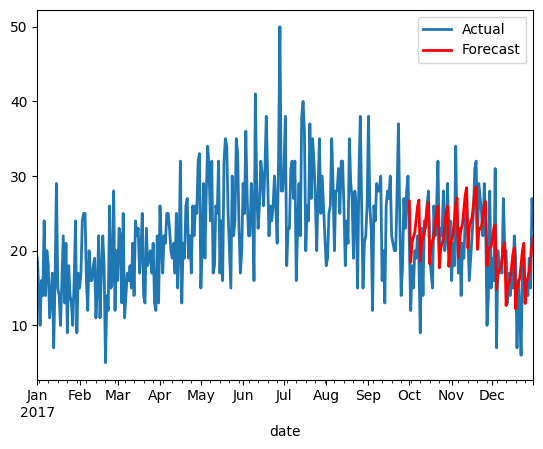

Ця мождель дає найкрпащій результат MAPE: 23.80%

15. Натренуйте модель `RNNModel` та зробіть висновок про її якість.

In [ ]:
from darts.models import RNNModel

model_rnn = RNNModel(model='LSTM', input_chunk_length=12, n_epochs=300)
model_rnn.fit(train)

# Прогнозування
forecast = model_rnn.predict(len(val))

# Візуалізація результатів
series.plot(label='Actual')
forecast.plot(label='Forecast', color='red')
fit_and_plot(model_rnn, series, train, val)


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ criterion       │ MSELoss          │      0 │ train │     0 │
│ 1 │ train_criterion │ MSELoss          │      0 │ train │     0 │
│ 2 │ val_criterion   │ MSELoss          │      0 │ train │     0 │
│ 3 │ train_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ val_metrics     │ MetricCollection │      0 │ train │     0 │
│ 5 │ rnn             │ LSTM             │  2.8 K │ train │     0 │
│ 6 │ V               │ Linear           │     26 │ train │     0 │
└───┴─────────────────┴──────────────────┴────────┴───────┴───────┘
Trainable params: 2.8 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.8 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 7                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0                                                                                                     
Epoch 299/299 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54/54 0:00:01 • 0:00:00 35.67it/s train_loss: 23.957
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=300` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Predicting ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/1 0:00:00 • 0:00:00 0.00it/s  
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ criterion       │ MSELoss          │      0 │ train │     0 │
│ 1 │ train_criterion │ MSELoss          │      0 │ train │     0 │
│ 2 │ val_criterion   │ MSELoss          │      0 │ train │     0 │
│ 3 │ train_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ val_metrics     │ MetricCollection │      0 │ train │     0 │
│ 5 │ rnn             │ LSTM             │  2.8 K │ train │     0 │
│ 6 │ V               │ Linear           │     26 │ train │     0 │
└───┴─────────────────┴──────────────────┴────────┴───────┴───────┘
Trainable params: 2.8 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.8 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 7                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0                                                                                                     
Epoch 299/299 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54/54 0:00:01 • 0:00:00 33.18it/s train_loss: 24.235
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=300` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Predicting ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/1 0:00:00 • 0:00:00 0.00it/s  


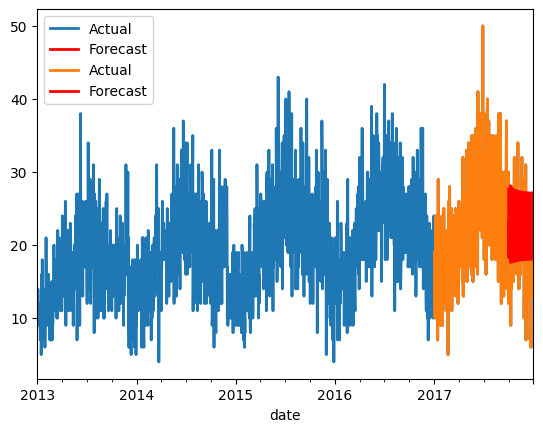

model RNNModel(model=LSTM, input_chunk_length=12, n_epochs=300) obtains MAPE: 32.69%

Якість моделі непогана але є моделі з нижчим значенням MAPE

16. Виконайте бектест для тої моделі, яка виявилась найкращою у вашому дослідженні на періоді 1 рік з передбаченнями на 1 місяць щоразу. Візуалізуйте як поводилась модель протягом бектесту, яка була точність?

найкращій результата дає модель Prophet (МАРЕ 23,8%), відповідно на ній будемо робити бектест

In [34]:
model_prop = Prophet()
model_prop.fit(train)

forecast = model_prop.predict(len(val))

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
hfc_params = {
    "series": series,
    "start": pd.Timestamp("2017-10-01"),
    "forecast_horizon": 3,
    "stride": 1,
    "verbose": True,
}

historical_fcast = model_prop.historical_forecasts(**hfc_params)
series_2017 = series.slice(pd.Timestamp("2017-01-01"), series.end_time())
series_2017.plot(label="data")
historical_fcast.plot(label="backtest 3-months ahead forecast")
print(f"MAPE = {mape(series, historical_fcast):.2f}%")

historical forecasts:   0%|          | 0/90 [00:00<?, ?it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:   1%|          | 1/90 [00:00<00:47,  1.86it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:   2%|▏         | 2/90 [00:01<00:54,  1.63it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:   3%|▎         | 3/90 [00:01<00:50,  1.73it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:   4%|▍         | 4/90 [00:02<00:41,  2.05it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:   6%|▌         | 5/90 [00:02<00:36,  2.33it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:   7%|▋         | 6/90 [00:02<00:32,  2.55it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:   8%|▊         | 7/90 [00:03<00:31,  2.60it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:   9%|▉         | 8/90 [00:03<00:29,  2.76it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  10%|█         | 9/90 [00:03<00:27,  2.91it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  11%|█         | 10/90 [00:04<00:26,  2.99it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  12%|█▏        | 11/90 [00:04<00:26,  3.04it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  13%|█▎        | 12/90 [00:04<00:26,  2.95it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  14%|█▍        | 13/90 [00:05<00:24,  3.09it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  16%|█▌        | 14/90 [00:05<00:24,  3.11it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  17%|█▋        | 15/90 [00:05<00:24,  3.09it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  18%|█▊        | 16/90 [00:06<00:24,  2.97it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  19%|█▉        | 17/90 [00:06<00:23,  3.04it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  20%|██        | 18/90 [00:06<00:23,  3.09it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  21%|██        | 19/90 [00:06<00:23,  3.08it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  22%|██▏       | 20/90 [00:07<00:23,  3.02it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  23%|██▎       | 21/90 [00:07<00:22,  3.12it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  24%|██▍       | 22/90 [00:07<00:22,  3.00it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  26%|██▌       | 23/90 [00:08<00:22,  3.01it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  27%|██▋       | 24/90 [00:08<00:22,  2.90it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  28%|██▊       | 25/90 [00:08<00:21,  3.07it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  29%|██▉       | 26/90 [00:09<00:20,  3.16it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  30%|███       | 27/90 [00:09<00:20,  3.02it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  31%|███       | 28/90 [00:09<00:20,  3.06it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  32%|███▏      | 29/90 [00:10<00:19,  3.06it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  33%|███▎      | 30/90 [00:10<00:20,  2.93it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  34%|███▍      | 31/90 [00:11<00:29,  1.97it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  36%|███▌      | 32/90 [00:11<00:25,  2.26it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  37%|███▋      | 33/90 [00:12<00:25,  2.20it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  38%|███▊      | 34/90 [00:12<00:27,  2.07it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  39%|███▉      | 35/90 [00:13<00:26,  2.05it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  40%|████      | 36/90 [00:14<00:29,  1.86it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  41%|████      | 37/90 [00:14<00:27,  1.89it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  42%|████▏     | 38/90 [00:15<00:27,  1.87it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  43%|████▎     | 39/90 [00:15<00:24,  2.06it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  44%|████▍     | 40/90 [00:15<00:21,  2.32it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  46%|████▌     | 41/90 [00:16<00:19,  2.48it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  47%|████▋     | 42/90 [00:16<00:17,  2.75it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  48%|████▊     | 43/90 [00:16<00:16,  2.93it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  49%|████▉     | 44/90 [00:16<00:15,  3.01it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  50%|█████     | 45/90 [00:17<00:14,  3.02it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  51%|█████     | 46/90 [00:17<00:14,  3.07it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  52%|█████▏    | 47/90 [00:17<00:13,  3.15it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  53%|█████▎    | 48/90 [00:18<00:13,  3.18it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  54%|█████▍    | 49/90 [00:18<00:12,  3.17it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  56%|█████▌    | 50/90 [00:18<00:12,  3.16it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  57%|█████▋    | 51/90 [00:19<00:12,  3.12it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  58%|█████▊    | 52/90 [00:19<00:11,  3.28it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  59%|█████▉    | 53/90 [00:19<00:11,  3.23it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  60%|██████    | 54/90 [00:20<00:11,  3.05it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  61%|██████    | 55/90 [00:20<00:11,  3.01it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  62%|██████▏   | 56/90 [00:20<00:10,  3.15it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  63%|██████▎   | 57/90 [00:21<00:10,  3.19it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  64%|██████▍   | 58/90 [00:21<00:09,  3.23it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  66%|██████▌   | 59/90 [00:21<00:09,  3.11it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  67%|██████▋   | 60/90 [00:22<00:09,  3.12it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  68%|██████▊   | 61/90 [00:22<00:09,  3.18it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  69%|██████▉   | 62/90 [00:22<00:09,  3.11it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  70%|███████   | 63/90 [00:22<00:08,  3.10it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  71%|███████   | 64/90 [00:23<00:08,  3.13it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  72%|███████▏  | 65/90 [00:23<00:07,  3.13it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  73%|███████▎  | 66/90 [00:24<00:08,  2.93it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  74%|███████▍  | 67/90 [00:24<00:07,  2.90it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  76%|███████▌  | 68/90 [00:24<00:07,  2.93it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  77%|███████▋  | 69/90 [00:24<00:06,  3.07it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  78%|███████▊  | 70/90 [00:25<00:07,  2.73it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  79%|███████▉  | 71/90 [00:26<00:08,  2.28it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  80%|████████  | 72/90 [00:26<00:08,  2.16it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  81%|████████  | 73/90 [00:27<00:08,  2.10it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  82%|████████▏ | 74/90 [00:27<00:07,  2.01it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  83%|████████▎ | 75/90 [00:28<00:07,  1.89it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  84%|████████▍ | 76/90 [00:28<00:07,  1.91it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  86%|████████▌ | 77/90 [00:29<00:05,  2.17it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  87%|████████▋ | 78/90 [00:29<00:05,  2.33it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  88%|████████▊ | 79/90 [00:29<00:04,  2.50it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  89%|████████▉ | 80/90 [00:30<00:03,  2.65it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  90%|█████████ | 81/90 [00:30<00:03,  2.68it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  91%|█████████ | 82/90 [00:30<00:02,  2.71it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  92%|█████████▏| 83/90 [00:31<00:02,  2.66it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  93%|█████████▎| 84/90 [00:31<00:02,  2.72it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  94%|█████████▍| 85/90 [00:31<00:01,  2.79it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  96%|█████████▌| 86/90 [00:32<00:01,  2.79it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  97%|█████████▋| 87/90 [00:32<00:01,  2.80it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  98%|█████████▊| 88/90 [00:32<00:00,  2.78it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts:  99%|█████████▉| 89/90 [00:33<00:00,  2.49it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
historical forecasts: 100%|██████████| 90/90 [00:34<00:00,  2.63it/s]
MAPE = 23.09%

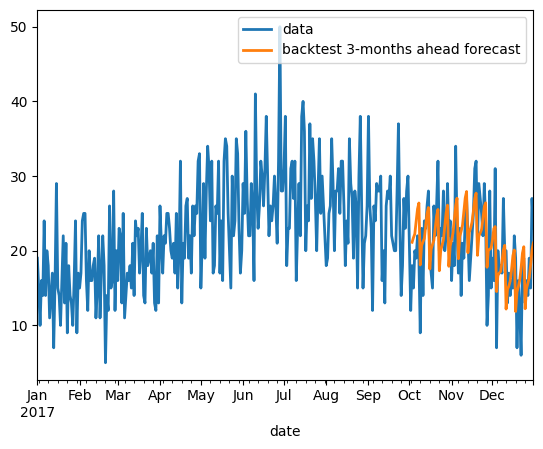

На поточний момент це найкращій результат МАРЕ = 23,09% при дослідженні на періоді 1 рік з передбаченнями на 1 місяць щоразу

17. На цьому етапі ви зрозуміли, як моделювати продажі одного айтему з 1 магазину. Як би ви підійшли до задачі прогнозування продажів в наступному місяці для кожного з 50 айтемів в кожному з 10 магазинів? Опишіть загальний підхід
- яку модель ви б використали
- скільки моделей ви б тренували
- обгрунтуйте свій вибір.

Для навчання всіх 50 товарів у 10 магазинах скоріше підійде модель XGBoost так як вона дає непоганий результат та здатна обробляти складні залежності та великі обсяги даних.

Якщо мождливо то тренувала б 1 модель з індикаторами товар (item) та магазин (store).
